# 📊 PHÂN TÍCH CỔ PHIẾU VIỆT NAM - NÂNG CAO

## Tính năng:
- ✅ Sử dụng API key (60 requests/phút)
- 📈 Phân tích VNINDEX
- 🏭 Phân tích 8 ngành chính
- 📊 Top tăng/giảm mạnh nhất
- 💾 Xuất dữ liệu ra Excel
- 📉 Biểu đồ trực quan

## 1. Cài đặt và Import

In [11]:
# Cài đặt thư viện (chỉ chạy lần đầu)
# !pip install vnstock pandas matplotlib seaborn openpyxl

In [12]:
import os
import time
from datetime import datetime, timedelta
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

# ===== SET API KEY =====
os.environ['VNSTOCK_API_KEY'] = "vnstock_f9670e0e442e7dbca5ef85109908fc63"

from vnstock import Vnstock

print("✅ Import thành công!")
print(f"⏰ Thời gian: {datetime.now().strftime('%d/%m/%Y %H:%M:%S')}")
print(f"🔑 API Key: {'*' * 20}{os.environ['VNSTOCK_API_KEY'][-10:]}")
print("📊 Giới hạn: 60 requests/phút")

✅ Import thành công!
⏰ Thời gian: 27/01/2026 00:23:09
🔑 API Key: ********************109908fc63
📊 Giới hạn: 60 requests/phút


## 2. Cấu hình

In [13]:
# Danh sách ngành và mã cổ phiếu
SECTORS = {
    'Ngân hàng': ['VCB', 'BID', 'CTG', 'TCB', 'MBB'],
    'Bất động sản': ['VHM', 'VIC', 'NVL', 'DXG'],
    'Thép': ['HPG', 'HSG', 'NKG'],
    'Thực phẩm': ['VNM', 'MSN', 'SAB'],
    'Dầu khí': ['GAS', 'PLX', 'PVD'],
    'Bán lẻ': ['MWG', 'FRT', 'PNJ'],
    'Chứng khoán': ['SSI', 'VND', 'HCM'],
    'Công nghệ': ['FPT', 'CMG', 'VGI']
}

# Khoảng thời gian
end_date = datetime.now().strftime('%Y-%m-%d')
start_date = (datetime.now() - timedelta(days=30)).strftime('%Y-%m-%d')

print(f"📅 Phân tích từ {start_date} đến {end_date}")
print(f"🏭 Số ngành: {len(SECTORS)}")
print(f"📈 Tổng số mã: {sum(len(v) for v in SECTORS.values())}")

📅 Phân tích từ 2025-12-28 đến 2026-01-27
🏭 Số ngành: 8
📈 Tổng số mã: 27


## 3. Lấy chỉ số VNINDEX

In [14]:
print("🔄 Đang lấy dữ liệu VNINDEX...\n")

try:
    stock = Vnstock().stock(symbol='VNINDEX', source='VCI')
    vnindex_data = stock.quote.history(start=start_date, end=end_date, interval='1D')
    
    if vnindex_data is not None and not vnindex_data.empty:
        latest = vnindex_data.iloc[-1]
        prev = vnindex_data.iloc[-2] if len(vnindex_data) >= 2 else latest
        change = latest['close'] - prev['close']
        pct_change = (change / prev['close']) * 100
        
        print("="*70)
        print(f"{'CHỈ SỐ VNINDEX':^70}")
        print("="*70)
        print(f"Điểm số:        {latest['close']:.2f} điểm")
        print(f"Biến động:      {'📈' if change > 0 else '📉'} {change:+.2f} ({pct_change:+.2f}%)")
        print(f"Cao nhất:       {latest['high']:.2f}")
        print(f"Thấp nhất:      {latest['low']:.2f}")
        print(f"Khối lượng:     {latest['volume']:,.0f}")
        print("="*70)
        
        vnindex_latest = latest
        vnindex_change = change
    else:
        print("⚠️ Không lấy được dữ liệu VNINDEX")
        vnindex_data = None
except Exception as e:
    print(f"❌ Lỗi: {e}")
    vnindex_data = None

2026-01-27 00:23:09 - vnstock.common.data - INFO - Not a stock. Company and finance data unavailable.


🔄 Đang lấy dữ liệu VNINDEX...

                            CHỈ SỐ VNINDEX                            
Điểm số:        1843.72 điểm
Biến động:      📉 -27.07 (-1.45%)
Cao nhất:       1879.45
Thấp nhất:      1833.21
Khối lượng:     1,112,553,302


## 4. Biểu đồ VNINDEX

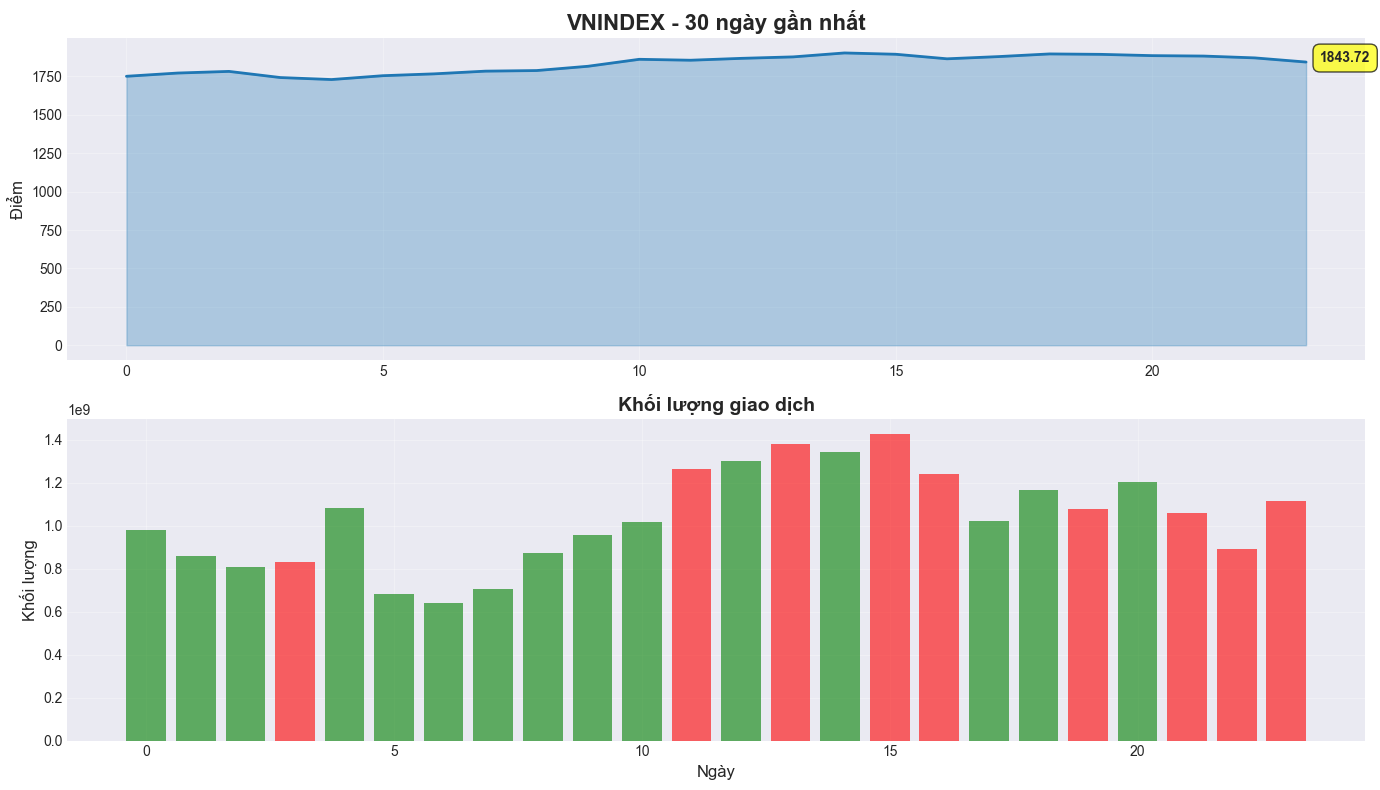

In [15]:
if vnindex_data is not None and not vnindex_data.empty:
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))
    
    # Biểu đồ giá
    ax1.plot(vnindex_data.index, vnindex_data['close'], linewidth=2, color='#1f77b4')
    ax1.fill_between(vnindex_data.index, vnindex_data['close'], alpha=0.3, color='#1f77b4')
    ax1.set_title('VNINDEX - 30 ngày gần nhất', fontsize=16, fontweight='bold')
    ax1.set_ylabel('Điểm', fontsize=12)
    ax1.grid(True, alpha=0.3)
    
    # Annotation
    last_price = vnindex_data['close'].iloc[-1]
    ax1.annotate(f'{last_price:.2f}', 
                xy=(vnindex_data.index[-1], last_price),
                xytext=(10, 0), textcoords='offset points',
                fontsize=10, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7))
    
    # Biểu đồ khối lượng
    colors = ['green' if vnindex_data['close'].iloc[i] >= vnindex_data['open'].iloc[i] else 'red' 
              for i in range(len(vnindex_data))]
    ax2.bar(vnindex_data.index, vnindex_data['volume'], color=colors, alpha=0.6)
    ax2.set_title('Khối lượng giao dịch', fontsize=14, fontweight='bold')
    ax2.set_ylabel('Khối lượng', fontsize=12)
    ax2.set_xlabel('Ngày', fontsize=12)
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ Không có dữ liệu để vẽ biểu đồ")

## 5. Lấy dữ liệu theo ngành

In [16]:
print("🔄 Đang lấy dữ liệu theo ngành...\n")

all_data = []
sector_results = {}

for sector, symbols in SECTORS.items():
    print(f"\n{'='*70}")
    print(f"🏭 {sector.upper()}")
    print("="*70)
    
    sector_data = []
    
    for symbol in symbols:
        try:
            stock_obj = Vnstock().stock(symbol=symbol, source='VCI')
            hist = stock_obj.quote.history(start=start_date, end=end_date, interval='1D')
            
            if hist is not None and not hist.empty:
                latest = hist.iloc[-1]
                prev = hist.iloc[-2] if len(hist) >= 2 else latest
                change = latest['close'] - prev['close']
                pct_change = (change / prev['close']) * 100
                
                data = {
                    'Ngành': sector,
                    'Mã': symbol,
                    'Giá': latest['close'],
                    'Thay đổi': change,
                    '%': pct_change,
                    'Khối lượng': latest['volume'],
                    'Cao': latest['high'],
                    'Thấp': latest['low']
                }
                sector_data.append(data)
                all_data.append(data)
                
                print(f"  {symbol:5s} | {latest['close']:>8,.0f} | {change:>+6.1f} | {pct_change:>+6.2f}%")
            
            # Delay 1 giây để tránh vượt giới hạn
            time.sleep(1)
            
        except Exception as e:
            print(f"  {symbol:5s} | ⚠️ Lỗi: {str(e)[:40]}")
    
    if sector_data:
        sector_results[sector] = pd.DataFrame(sector_data)
    else:
        print("  ⚠️ Không có dữ liệu")

print("\n✅ Hoàn thành lấy dữ liệu!")

🔄 Đang lấy dữ liệu theo ngành...


🏭 NGÂN HÀNG
  VCB   |       70 |   +1.0 |  +1.46%
  BID   |       52 |   +1.7 |  +3.35%
  CTG   |       38 |   -0.8 |  -2.05%
  TCB   |       36 |   -0.9 |  -2.33%
  MBB   |       26 |   -0.8 |  -3.15%

🏭 BẤT ĐỘNG SẢN
  VHM   |      119 |   -3.6 |  -2.94%
  VIC   |      160 |   -5.5 |  -3.33%
  NVL   |       12 |   -0.7 |  -5.20%
  DXG   |       15 |   -0.7 |  -4.25%

🏭 THÉP
  HPG   |       26 |   -0.4 |  -1.68%
  HSG   |       16 |   -0.5 |  -2.75%
  NKG   |       15 |   -0.5 |  -3.26%

🏭 THỰC PHẨM
  VNM   |       69 |   +1.7 |  +2.53%
  MSN   |       77 |   -1.7 |  -2.15%
  SAB   |       48 |   -0.8 |  -1.62%

🏭 DẦU KHÍ
  GAS   |      108 |   +7.0 |  +6.94%
  PLX   |       57 |   +2.4 |  +4.40%
  PVD   |       27 |   -0.2 |  -0.72%

🏭 BÁN LẺ
  MWG   |       84 |   -1.7 |  -1.98%
  FRT   |      145 |   -6.7 |  -4.41%
  PNJ   |      117 |   +4.4 |  +3.91%

🏭 CHỨNG KHOÁN
  SSI   |       31 |   -0.9 |  -2.82%
  VND   |       18 |   -0.9 |  -4.64%
  HCM 

## 6. Tổng hợp và phân tích

In [17]:
if all_data:
    df_all = pd.DataFrame(all_data)
    
    print("\n" + "="*70)
    print(f"{'TỔNG HỢP PHÂN TÍCH':^70}")
    print("="*70)
    
    # Top tăng
    print("\n🏆 TOP 5 TĂNG MẠNH NHẤT:")
    top_gain = df_all.nlargest(5, '%')[['Mã', 'Giá', '%', 'Ngành']]
    print(top_gain.to_string(index=False))
    
    # Top giảm
    print("\n📉 TOP 5 GIẢM MẠNH NHẤT:")
    top_loss = df_all.nsmallest(5, '%')[['Mã', 'Giá', '%', 'Ngành']]
    print(top_loss.to_string(index=False))
    
    # Thống kê
    print("\n📊 THỐNG KÊ:")
    tang = (df_all['%'] > 0).sum()
    giam = (df_all['%'] < 0).sum()
    dung = (df_all['%'] == 0).sum()
    
    print(f"  Số mã tăng:      {tang}")
    print(f"  Số mã giảm:      {giam}")
    print(f"  Số mã đứng giá:  {dung}")
    print(f"  Tổng:            {len(df_all)}")
    print("="*70)
else:
    print("⚠️ Không có dữ liệu")
    df_all = None


                          TỔNG HỢP PHÂN TÍCH                          

🏆 TOP 5 TĂNG MẠNH NHẤT:
 Mã   Giá        %     Ngành
GAS 107.8 6.944444   Dầu khí
VGI 124.0 6.896552 Công nghệ
PLX  57.0 4.395604   Dầu khí
PNJ 116.8 3.914591    Bán lẻ
BID  52.5 3.346457 Ngân hàng

📉 TOP 5 GIẢM MẠNH NHẤT:
 Mã    Giá         %        Ngành
NVL  11.85 -5.200000 Bất động sản
VND  18.50 -4.639175  Chứng khoán
FRT 145.10 -4.413702       Bán lẻ
DXG  14.65 -4.248366 Bất động sản
VIC 159.90 -3.325272 Bất động sản

📊 THỐNG KÊ:
  Số mã tăng:      7
  Số mã giảm:      20
  Số mã đứng giá:  0
  Tổng:            27


## 7. Biểu đồ phân tích

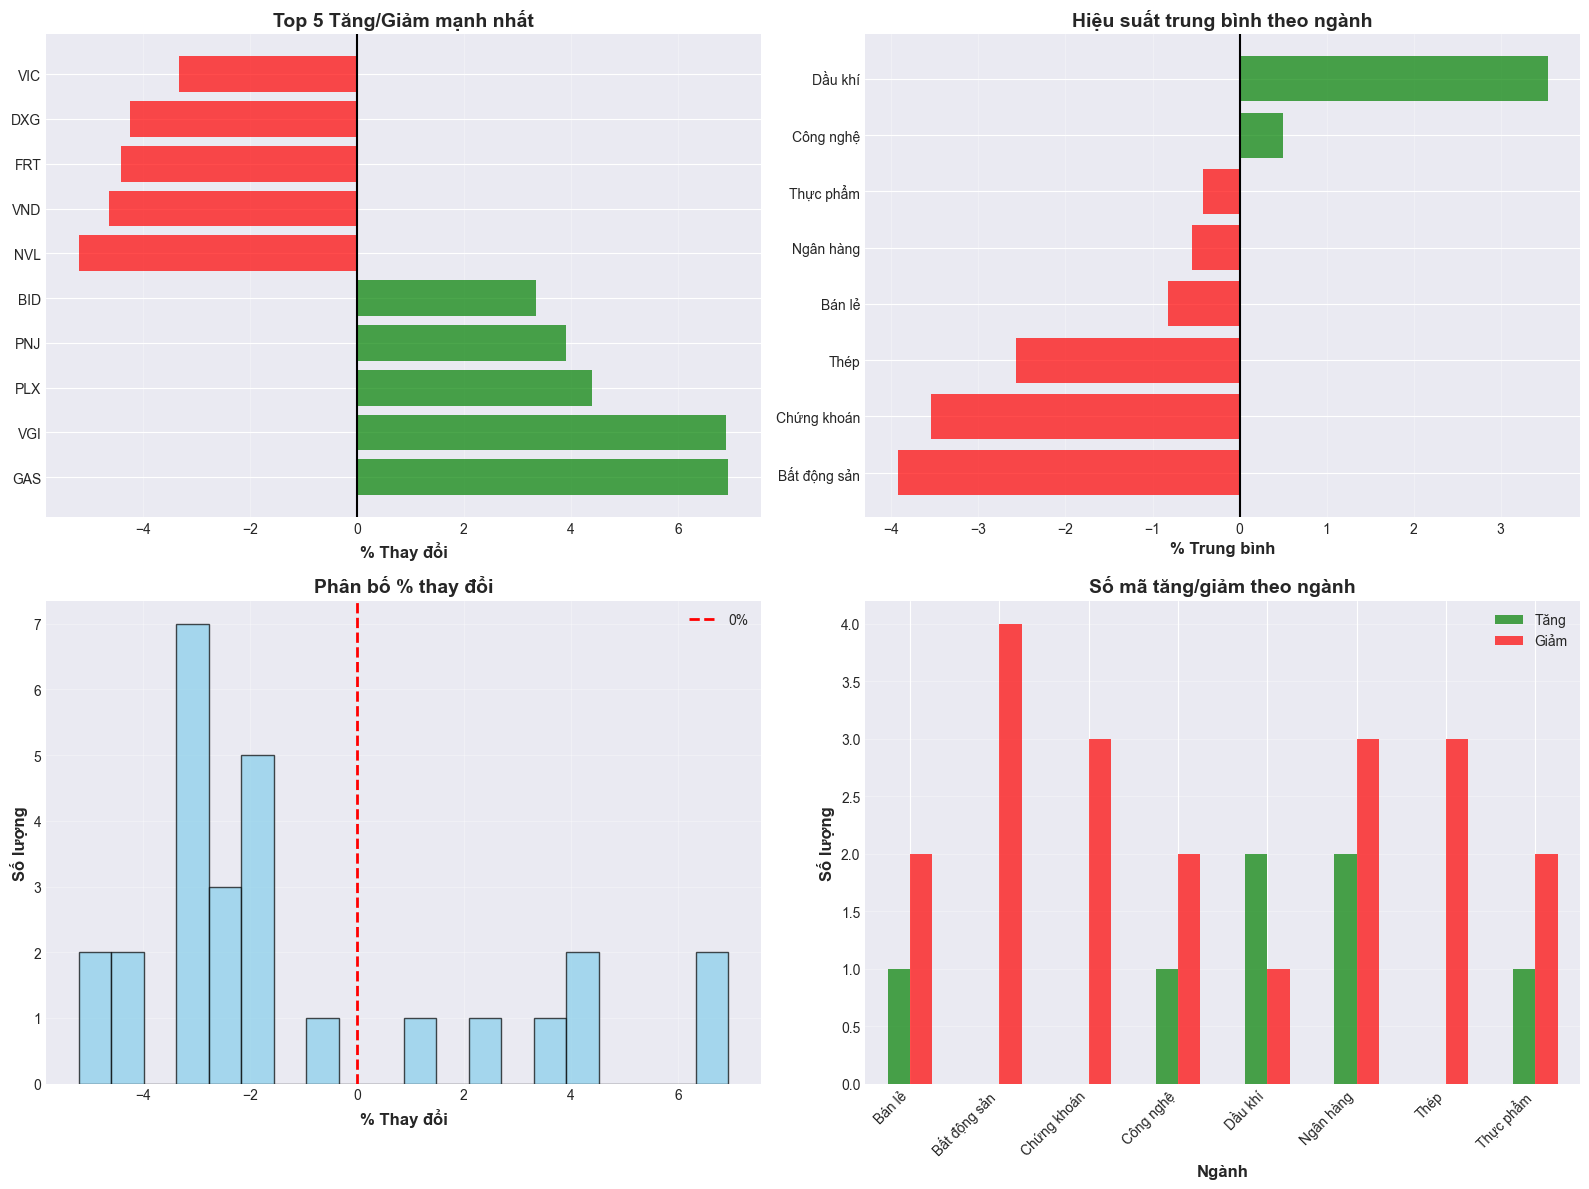

In [18]:
if df_all is not None and not df_all.empty:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # 1. Top 10 tăng/giảm
    ax1 = axes[0, 0]
    top10 = pd.concat([df_all.nlargest(5, '%'), df_all.nsmallest(5, '%')])
    colors = ['green' if x > 0 else 'red' for x in top10['%']]
    ax1.barh(top10['Mã'], top10['%'], color=colors, alpha=0.7)
    ax1.set_xlabel('% Thay đổi', fontsize=12, fontweight='bold')
    ax1.set_title('Top 5 Tăng/Giảm mạnh nhất', fontsize=14, fontweight='bold')
    ax1.axvline(x=0, color='black', linewidth=1.5)
    ax1.grid(True, alpha=0.3, axis='x')
    
    # 2. Phân bố theo ngành
    ax2 = axes[0, 1]
    sector_avg = df_all.groupby('Ngành')['%'].mean().sort_values()
    colors2 = ['green' if x > 0 else 'red' for x in sector_avg]
    ax2.barh(sector_avg.index, sector_avg.values, color=colors2, alpha=0.7)
    ax2.set_xlabel('% Trung bình', fontsize=12, fontweight='bold')
    ax2.set_title('Hiệu suất trung bình theo ngành', fontsize=14, fontweight='bold')
    ax2.axvline(x=0, color='black', linewidth=1.5)
    ax2.grid(True, alpha=0.3, axis='x')
    
    # 3. Phân bố % thay đổi
    ax3 = axes[1, 0]
    ax3.hist(df_all['%'], bins=20, color='skyblue', edgecolor='black', alpha=0.7)
    ax3.axvline(x=0, color='red', linestyle='--', linewidth=2, label='0%')
    ax3.set_xlabel('% Thay đổi', fontsize=12, fontweight='bold')
    ax3.set_ylabel('Số lượng', fontsize=12, fontweight='bold')
    ax3.set_title('Phân bố % thay đổi', fontsize=14, fontweight='bold')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # 4. Số lượng tăng/giảm theo ngành
    ax4 = axes[1, 1]
    sector_count = df_all.groupby('Ngành').apply(
        lambda x: pd.Series({
            'Tăng': (x['%'] > 0).sum(),
            'Giảm': (x['%'] < 0).sum()
        })
    )
    sector_count.plot(kind='bar', ax=ax4, color=['green', 'red'], alpha=0.7)
    ax4.set_xlabel('Ngành', fontsize=12, fontweight='bold')
    ax4.set_ylabel('Số lượng', fontsize=12, fontweight='bold')
    ax4.set_title('Số mã tăng/giảm theo ngành', fontsize=14, fontweight='bold')
    ax4.legend(['Tăng', 'Giảm'])
    ax4.grid(True, alpha=0.3, axis='y')
    plt.setp(ax4.xaxis.get_majorticklabels(), rotation=45, ha='right')
    
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ Không có dữ liệu để vẽ biểu đồ")

## 8. Xuất dữ liệu ra Excel

In [19]:
os.chdir(os.path.join(os.environ['USERPROFILE'], 'Downloads'))
if df_all is not None and not df_all.empty:
    filename = f"phan_tich_co_phieu_{datetime.now().strftime('%Y%m%d_%H%M%S')}.xlsx"
    
    try:
        with pd.ExcelWriter(filename, engine='openpyxl') as writer:
            # Sheet 1: Tất cả dữ liệu
            df_all.to_excel(writer, sheet_name='Tất cả', index=False)
            
            # Sheet 2: Top tăng/giảm
            top_combined = pd.concat([
                df_all.nlargest(10, '%'),
                df_all.nsmallest(10, '%')
            ])
            top_combined.to_excel(writer, sheet_name='Top Tăng Giảm', index=False)
            
            # Sheet 3-N: Từng ngành
            for sector, df_sector in sector_results.items():
                sheet_name = sector[:31]  # Excel giới hạn 31 ký tự
                df_sector.to_excel(writer, sheet_name=sheet_name, index=False)
        
        print(f"✅ Đã xuất dữ liệu ra file: {filename}")
    except Exception as e:
        print(f"❌ Lỗi khi xuất Excel: {e}")
else:
    print("⚠️ Không có dữ liệu để xuất")

✅ Đã xuất dữ liệu ra file: phan_tich_co_phieu_20260127_002629.xlsx


## 9. Tóm tắt và khuyến nghị

In [20]:
if df_all is not None and not df_all.empty:
    print("\n" + "="*70)
    print(f"{'TÓM TẮT VÀ KHUYẾN NGHỊ':^70}")
    print("="*70)
    
    # Ngành tốt nhất
    sector_perf = df_all.groupby('Ngành')['%'].mean().sort_values(ascending=False)
    best_sector = sector_perf.index[0]
    worst_sector = sector_perf.index[-1]
    
    print(f"\n🌟 Ngành tốt nhất: {best_sector} ({sector_perf.iloc[0]:+.2f}%)")
    print(f"📉 Ngành yếu nhất: {worst_sector} ({sector_perf.iloc[-1]:+.2f}%)")
    
    # Top 3 đáng chú ý
    print("\n🎯 TOP 3 CỔ PHIẾU ĐÁNG CHÚ Ý:\n")
    top3 = df_all.nlargest(3, '%')
    for i, (idx, row) in enumerate(top3.iterrows(), 1):
        print(f"{i}. {row['Mã']} ({row['Ngành']})")
        print(f"   • Giá: {row['Giá']:,.0f} VND")
        print(f"   • Tăng: {row['%']:+.2f}%")
        print()
    
    print("⚠️ LƯU Ý:")
    print("  • Đây chỉ là phân tích kỹ thuật dựa trên giá")
    print("  • Cần xem xét thêm: Tin tức, báo cáo tài chính, xu hướng ngành")
    print("  • Đa dạng hóa danh mục để giảm rủi ro")
    print("  • Tham khảo ý kiến chuyên gia trước khi đầu tư")
    print("="*70)
else:
    print("⚠️ Không có dữ liệu")


                        TÓM TẮT VÀ KHUYẾN NGHỊ                        

🌟 Ngành tốt nhất: Dầu khí (+3.54%)
📉 Ngành yếu nhất: Bất động sản (-3.93%)

🎯 TOP 3 CỔ PHIẾU ĐÁNG CHÚ Ý:

1. GAS (Dầu khí)
   • Giá: 108 VND
   • Tăng: +6.94%

2. VGI (Công nghệ)
   • Giá: 124 VND
   • Tăng: +6.90%

3. PLX (Dầu khí)
   • Giá: 57 VND
   • Tăng: +4.40%

⚠️ LƯU Ý:
  • Đây chỉ là phân tích kỹ thuật dựa trên giá
  • Cần xem xét thêm: Tin tức, báo cáo tài chính, xu hướng ngành
  • Đa dạng hóa danh mục để giảm rủi ro
  • Tham khảo ý kiến chuyên gia trước khi đầu tư


---
## 📚 Hướng dẫn sử dụng

**Chạy notebook:**
1. Chọn `Cell > Run All` để chạy tất cả
2. Hoặc nhấn `Shift + Enter` từng cell

**Lưu ý:**
- API key đã được cấu hình sẵn (60 requests/phút)
- Có delay 1 giây giữa mỗi request để tránh spam
- Dữ liệu sẽ được xuất ra file Excel tự động

**Cập nhật:**
- Chạy lại notebook để lấy dữ liệu mới nhất
- Thay đổi danh sách mã cổ phiếu trong cell "Cấu hình"